In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recorded 

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
df["customerID"].duplicated().sum()

0

In [19]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

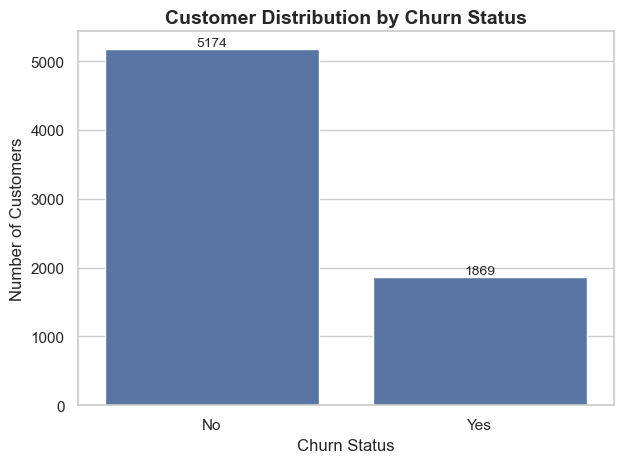

In [15]:
# Set style for better aesthetics
sns.set(style="whitegrid")

# Create count plot for Churn distribution
ax = sns.countplot(x='Churn', data=df)

# Add data labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

# Add title and labels
ax.set_title("Customer Distribution by Churn Status", fontsize=14, fontweight='bold')
ax.set_xlabel("Churn Status", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

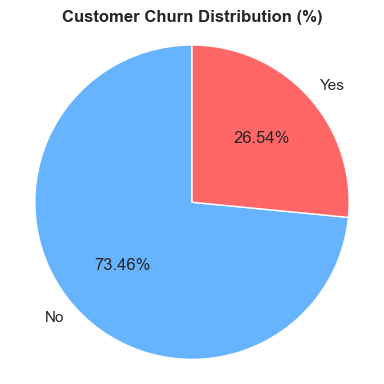

In [16]:
# Set figure size
plt.figure(figsize=(4, 4))

# Group data by Churn and count
churn_counts = df['Churn'].value_counts()

# Create pie chart
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=['#66b3ff', '#ff6666']
)

# Add title
plt.title("Customer Churn Distribution (%)", fontsize=12, fontweight='bold')

# Ensure pie is circular
plt.axis('equal')

# Display plot
plt.tight_layout()
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out. 
#not let's explore the reason behind it

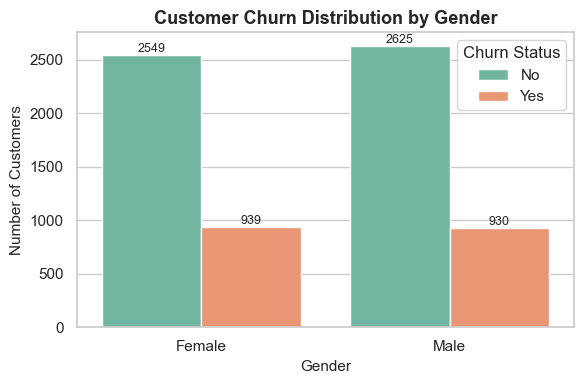

In [20]:
# Set style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(6, 4))

# Count plot with churn split by gender
ax = sns.countplot(x='gender', data=df, hue='Churn', palette='Set2')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

# Titles and labels
ax.set_title("Customer Churn Distribution by Gender", fontsize=13, fontweight='bold')
ax.set_xlabel("Gender", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)

# Legend title
ax.legend(title="Churn Status")

# Layout adjustment
plt.tight_layout()
plt.show()

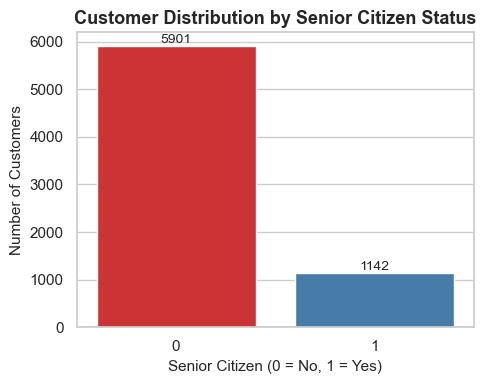

In [21]:
sns.set(style="whitegrid")

plt.figure(figsize=(5, 4))

# Assign hue = x and disable legend
ax = sns.countplot(x='SeniorCitizen', data=df, hue='SeniorCitizen', palette='Set1', legend=False)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

# Titles and labels
ax.set_title("Customer Distribution by Senior Citizen Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Senior Citizen (0 = No, 1 = Yes)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)

plt.tight_layout()
plt.show()

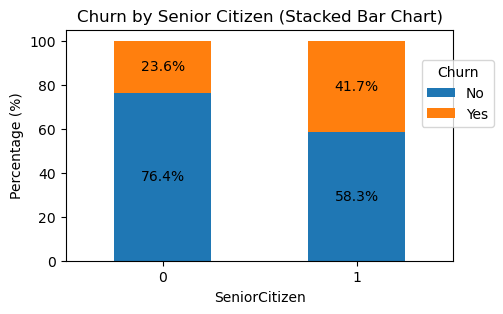

In [11]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(5, 3))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))  # Customize legend location

plt.show()

#comparative a greater pecentage of people in senior citizen category have churned

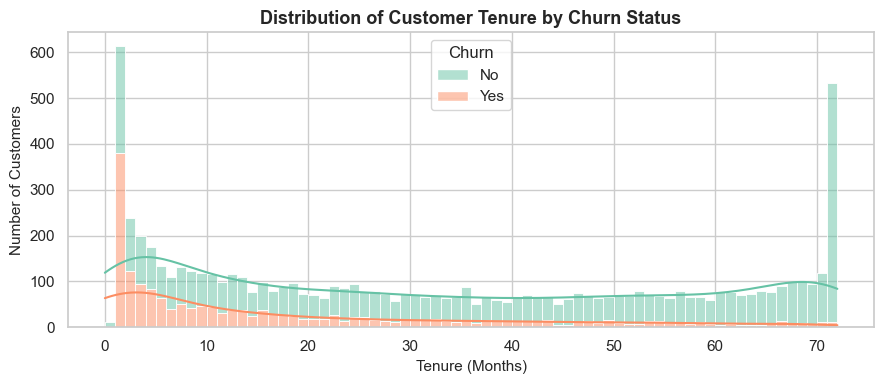

In [24]:
# Set style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(9, 4))

# Histogram with churn segmentation
ax = sns.histplot(
    data=df,
    x='tenure',
    bins=72,
    hue='Churn',
    kde=True,
    palette='Set2',
    multiple='stack'
)

# Titles and labels
ax.set_title("Distribution of Customer Tenure by Churn Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Tenure (Months)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)

# Layout adjustment
plt.tight_layout()
plt.show()

#people who have used our services for a long time have stayed and people who have used our sevices 
#1 or 2 months  have churned

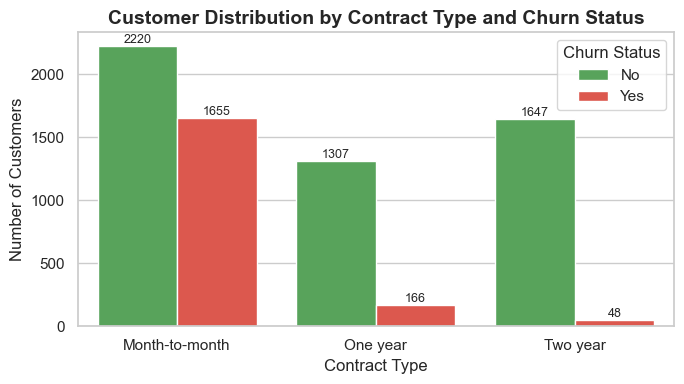

In [25]:
# Apply clean professional theme
sns.set_theme(style="whitegrid")
# Create figure
plt.figure(figsize=(7, 4))

# Count plot with churn segmentation
ax = sns.countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette={'No': '#4CAF50', 'Yes': '#F44336'}
)
# Add labels to all bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

# Titles and labels
ax.set_title("Customer Distribution by Contract Type and Churn Status",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Contract Type", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)

# Improve legend
ax.legend(title="Churn Status")

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 

In [76]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

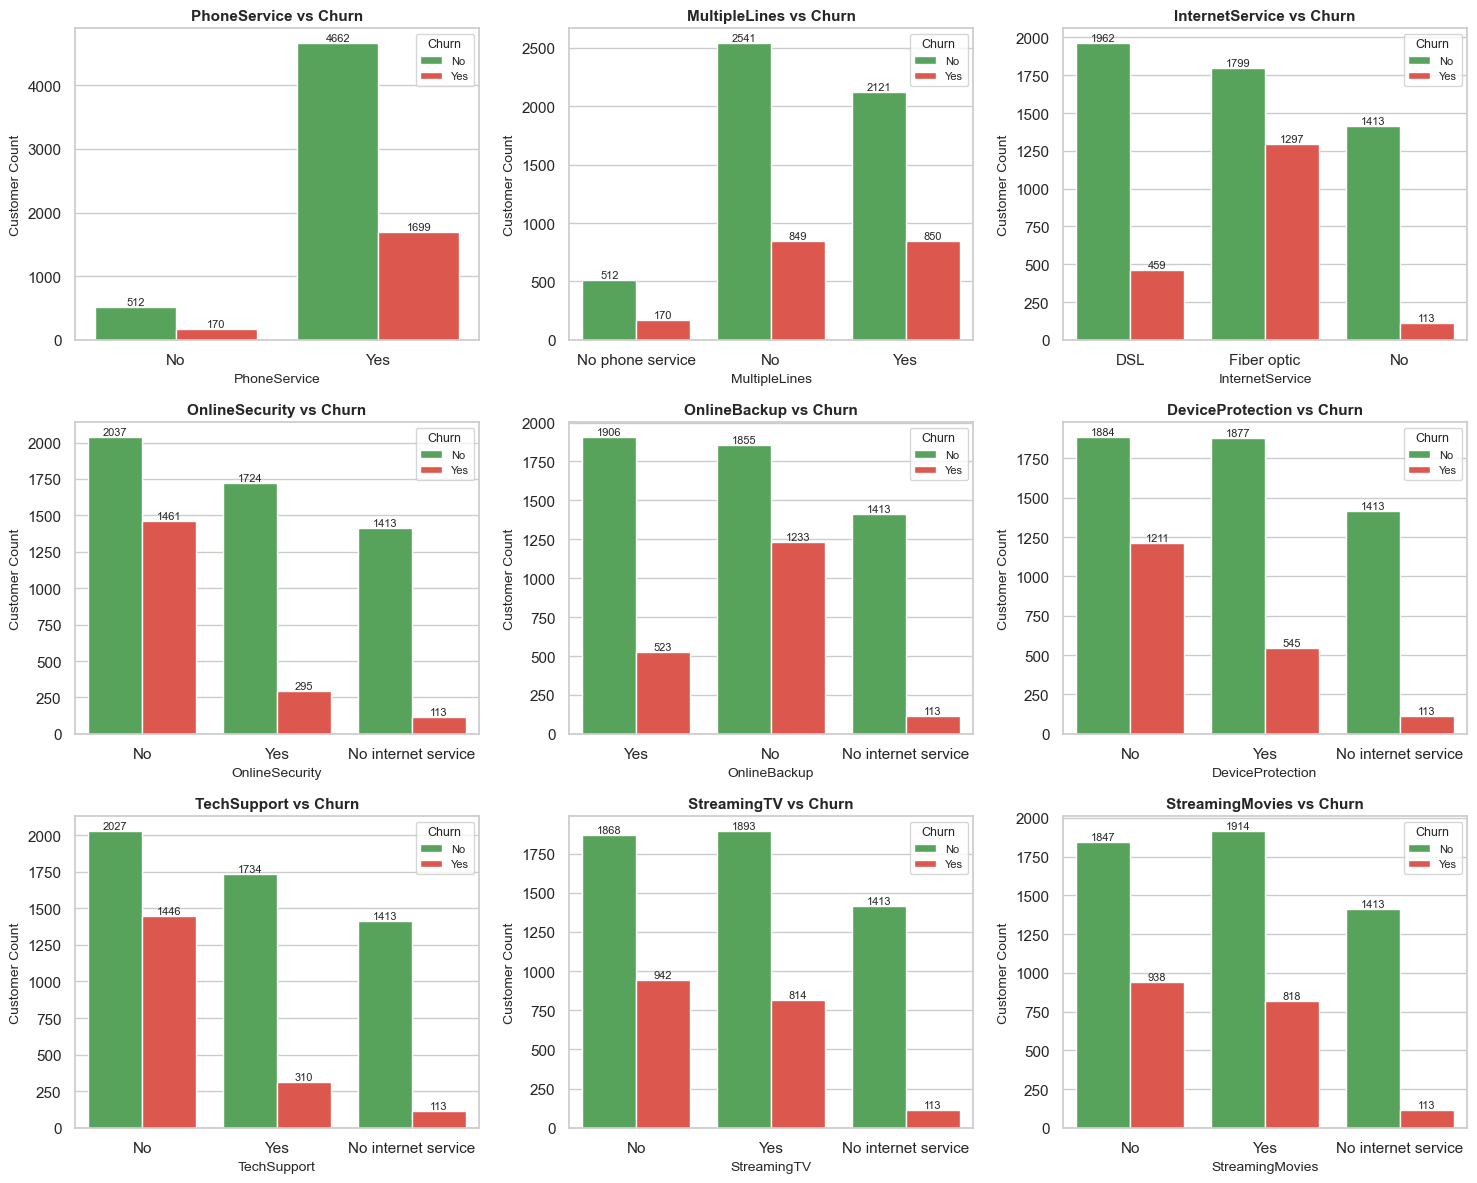

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply consistent theme
sns.set_theme(style="whitegrid")

# Columns to analyze
columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies'
]

# Grid configuration
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

# Plot each feature against churn
for i, col in enumerate(columns):
    ax = sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=axes[i],
        palette={'No': '#4CAF50', 'Yes': '#F44336'}
    )
    
    # Add bar labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=8)
    
    # Titles and labels
    ax.set_title(f"{col} vs Churn", fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Customer Count", fontsize=10)
    
    # Improve legend
    ax.legend(title="Churn", fontsize=8, title_fontsize=9)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

#The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable. 

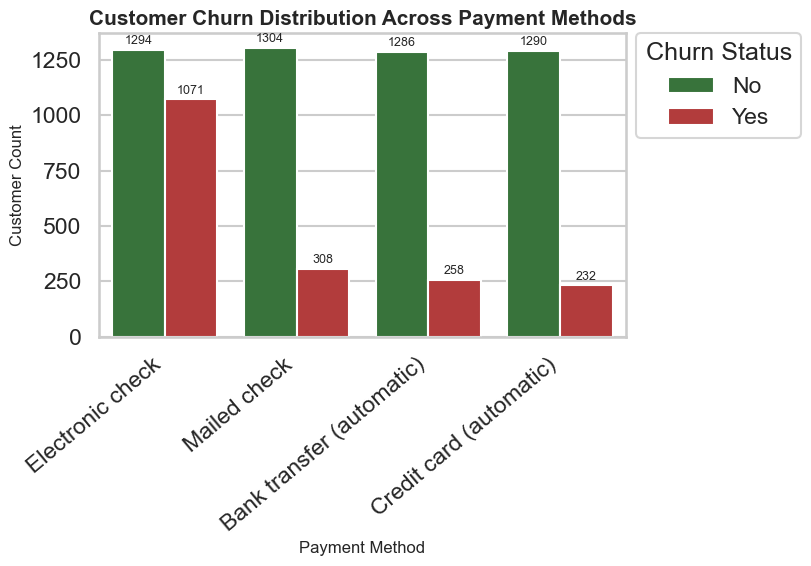

In [33]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn',
    palette={'No': '#2E7D32', 'Yes': '#C62828'}
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

# Titles and labels
ax.set_title("Customer Churn Distribution Across Payment Methods",
             fontsize=15, fontweight='bold')
ax.set_xlabel("Payment Method", fontsize=12)
ax.set_ylabel("Customer Count", fontsize=12)

# Rotate x labels
plt.xticks(rotation=40, ha='right')

# ✅ Move legend outside
ax.legend(
    title="Churn Status",
    bbox_to_anchor=(1.02, 1),   # position outside
    loc='upper left',
    borderaxespad=0
)

# Adjust layout to prevent cut-off
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

#customer is likely to churn when he is using electronic check as a payment method. 